In [1]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def getAllCategoryStatis(tiff_path,out_csv):
    # Open the TIFF file
    with rasterio.open(tiff_path) as src:
        band2 = src.read(1)  # Read Band  for SOC
        band1 = src.read(2)  # Read Band for landcover


    # Mask Band 2 where the value is 0 (considered empty pixels)
    band2_masked = np.where(band2 != 0, band2, np.nan)

    # Exclude zero values from Band 1
    valid_band1 = band1[band1 != 0]
    valid_band2 = band2_masked[band1 != 0]

    # Get unique values in Band 1 excluding 0
    unique_categories = np.unique(valid_band1)

    # Initialize a dictionary to store statistics
    stats = {"Category": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [], "Count": []}

    # Loop through each unique value in Band 1
    for category in unique_categories:
        # Create a mask for the current category in Band 1
        category_mask = valid_band1 == category
        
        # Extract corresponding Band 2 values
        selected_values = valid_band2[category_mask]
        
        # Exclude NaN values
        selected_values = selected_values[~np.isnan(selected_values)]
        
        # Skip if no valid values
        if len(selected_values) == 0:
            continue
        
        # Calculate statistics
        mean_value = np.mean(selected_values)
        range_value = np.ptp(selected_values)  # Range: max - min
        var_value = np.var(selected_values)
        min_value = np.min(selected_values)
        max_value = np.max(selected_values)
        count_value = len(selected_values)
        
        # Append statistics to the dictionary
        stats["Category"].append(int(category))
        stats["Mean"].append(mean_value)
        stats["Range"].append(range_value)
        stats["Variance"].append(var_value)
        stats["Min"].append(min_value)
        stats["Max"].append(max_value)
        stats["Count"].append(count_value)

    # Convert statistics to a DataFrame
    stats_df = pd.DataFrame(stats)

    # Print and save the table
    print(stats_df)
    stats_df.to_csv(out_csv, index=False)


In [15]:
def getAllCategoryStatis_update2(tiff_path,out_csv):
    # Open the TIFF file
    with rasterio.open(tiff_path) as src:
        band2 = src.read(1)  # Read Band  for SOC
        band1 = src.read(2)  # Read Band for landcover


    # Mask Band 2 where the value is 0 (considered empty pixels)
    band2_masked = np.where((band2 == 0) | (band2 > 1000 ) | (band2 < -1000), np.nan, band2)

    # Exclude zero values from Band 1
    valid_band1 = band1[band1 != 0]
    valid_band2 = band2_masked[band1 != 0]

    # Get unique values in Band 1 excluding 0
    unique_categories = np.unique(valid_band1)

    # Initialize a dictionary to store statistics
    stats = {"Category": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [], "Count": []}

    # Loop through each unique value in Band 1
    for category in unique_categories:
        # Create a mask for the current category in Band 1
        category_mask = valid_band1 == category
        
        # Extract corresponding Band 2 values
        selected_values = valid_band2[category_mask]
        
        # Exclude NaN values
        selected_values = selected_values[~np.isnan(selected_values)]
        
        # Skip if no valid values
        if len(selected_values) == 0:
            continue
        
        # Calculate statistics
        mean_value = np.mean(selected_values)
        range_value = np.ptp(selected_values)  # Range: max - min
        var_value = np.var(selected_values)
        min_value = np.min(selected_values)
        max_value = np.max(selected_values)
        count_value = len(selected_values)
        
        # Append statistics to the dictionary
        stats["Category"].append(int(category))
        stats["Mean"].append(mean_value)
        stats["Range"].append(range_value)
        stats["Variance"].append(var_value)
        stats["Min"].append(min_value)
        stats["Max"].append(max_value)
        stats["Count"].append(count_value)

    # Convert statistics to a DataFrame
    stats_df = pd.DataFrame(stats)

    # Print and save the table
    print(stats_df)
    stats_df.to_csv(out_csv, index=False)


In [2]:
# Path to the input TIFF file
tiff_path = "../FL_SOC_compose_Landcover.tif"

# Open the TIFF file
with rasterio.open(tiff_path) as src:
    band2 = src.read(1)  # Read Band  for SOC
    band1 = src.read(2)  # Read Band for landcover

# Mask the pixels in Band 2 where the value is 0 (empty pixels)
band2_masked = np.where(band2 != 0, band2, np.nan)

# Select pixels in Band 2 where Band 1 equals 5
selected_values = band2_masked[band1 == 52]

# Exclude NaN values for statistics calculation
selected_values = selected_values[~np.isnan(selected_values)]

# Calculate statistics
mean_value = np.mean(selected_values)
range_value = np.ptp(selected_values)  # Range: max - min
var_value = np.var(selected_values)

# Print the results
print(f"Mean: {mean_value}")
print(f"Range: {range_value}")
print(f"Variance: {var_value}")

Mean: 63.54915584258134
Range: 230.4742068341494
Variance: 426.94307358870975


       Group        Mean       Range     Variance
0     Forest   67.813514  224.556460   652.591823
1  Developed   67.324091  238.300959   796.731579
2      Grass   64.928016  232.628850   634.998233
3  Crop Land  106.326721  234.813221  6819.635330
4   Wetlands  113.918741  236.147616  3341.555660


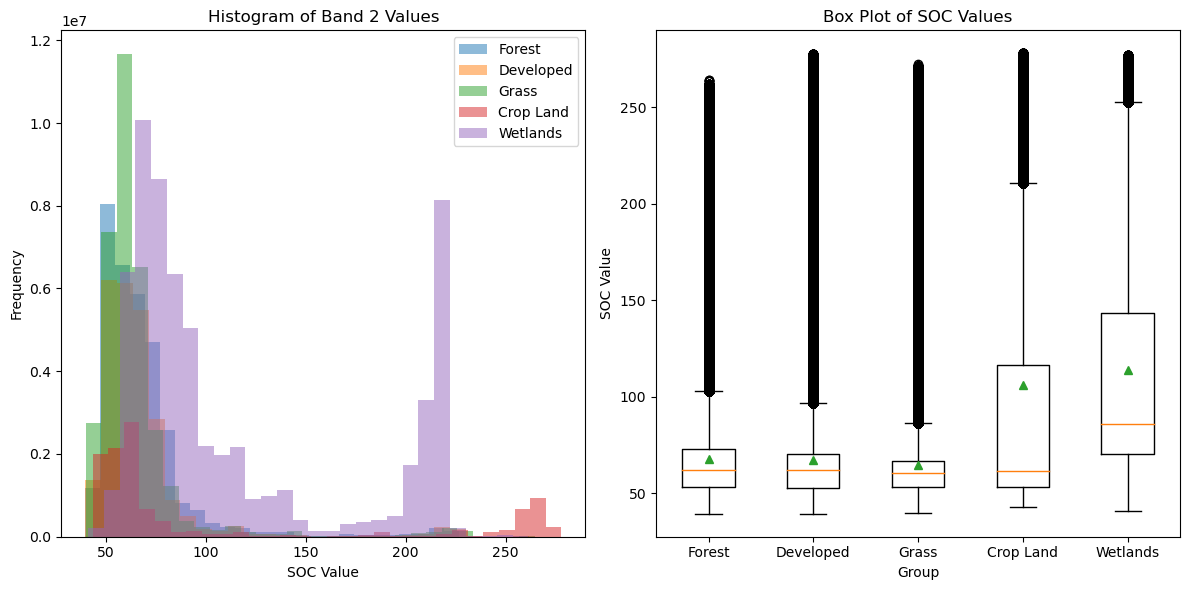

In [7]:
# 2008 tif
# Define your groups
categories = {
    "Forest": [41, 42, 43],
    "Developed": [21, 22, 23, 24],
    "Grass": [51, 52, 71, 81],
    "Crop Land": [82],
    "Wetlands": [90, 95]
}

# Path to the input TIFF file
tiff_path = "../FL_SOC_compose_Landcover.tif"

# Open the TIFF file
with rasterio.open(tiff_path) as src:
    band2 = src.read(1)  # Read Band  for SOC
    band1 = src.read(2)  # Read Band for landcover


# Mask Band 2 where value is 0 (empty pixels)
band2_masked = np.where(band2 != 0, band2, np.nan)

# Initialize a dictionary to store statistics
stats = {"Group": [], "Mean": [], "Range": [], "Variance": []}

# Loop through each group
for group_name, values in categories.items():
    # Create a mask for the current group
    group_mask = np.isin(band1, values)
    
    # Extract corresponding Band 2 values
    selected_values = band2_masked[group_mask]
    
    # Exclude NaN values
    selected_values = selected_values[~np.isnan(selected_values)]
    
    # Calculate statistics
    mean_value = np.mean(selected_values)
    range_value = np.ptp(selected_values)  # Range: max - min
    var_value = np.var(selected_values)
    
    # Append statistics to the dictionary
    stats["Group"].append(group_name)
    stats["Mean"].append(mean_value)
    stats["Range"].append(range_value)
    stats["Variance"].append(var_value)

# Convert statistics to a DataFrame
stats_df = pd.DataFrame(stats)
print(stats_df)

# Save the table as a CSV
stats_df.to_csv("group_statistics.csv", index=False)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Histogram
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    axs[0].hist(selected_values, bins=30, alpha=0.5, label=group_name)

axs[0].set_title("Histogram of Band 2 Values")
axs[0].set_xlabel("SOC Value")
axs[0].set_ylabel("Frequency")
axs[0].legend()

# Box Plot
box_data = []
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    box_data.append(selected_values)

axs[1].boxplot(box_data, labels=categories.keys(), showmeans=True)
axs[1].set_title("Box Plot of SOC Values")
axs[1].set_xlabel("Group")
axs[1].set_ylabel("SOC Value")

plt.tight_layout()
plt.savefig("group_statistics_plots.png")
plt.show()

       Group        Mean       Range     Variance        Min         Max
0     Forest   78.417036  223.207823  1738.155701  41.825631  265.033454
1  Developed   75.605612  233.092464  1428.636525  41.825631  274.918096
2      Grass   72.670494  229.666808  1393.242024  42.432885  272.099693
3      Shrub   73.231426  228.876556  1474.230587  41.825631  270.702187
4  Crop Land  109.359460  233.758073  6899.741425  43.546677  277.304750
5   Wetlands  112.322524  234.633691  3648.637081  41.825631  276.459322


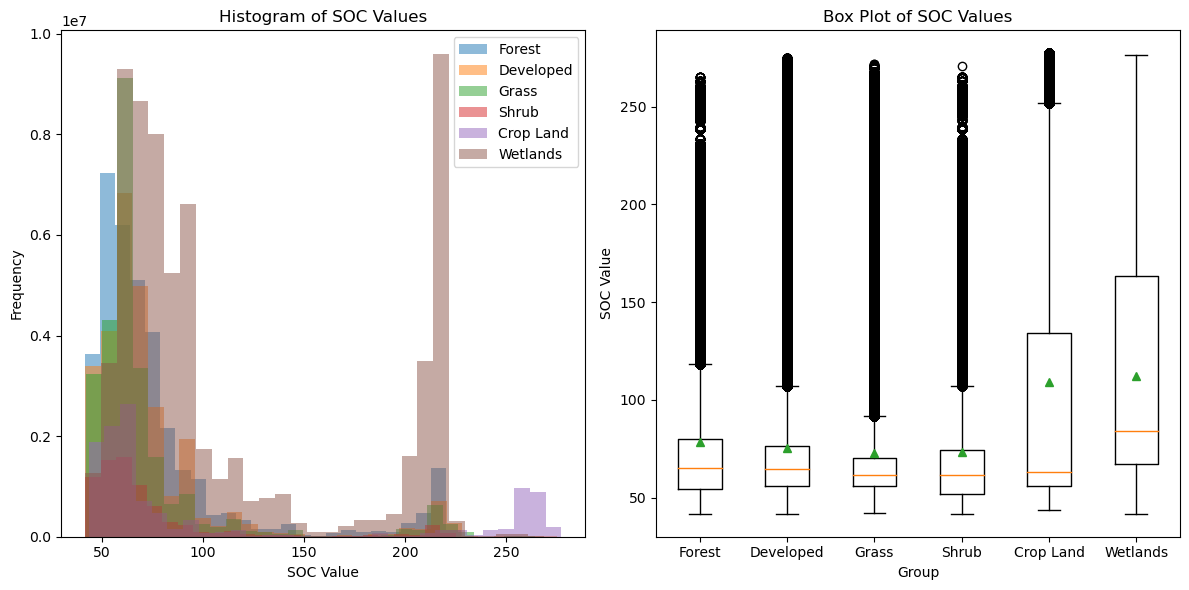

In [14]:
# 2021 landcover tif
# Define your groups
categories = {
    "Forest": [41, 42, 43],
    "Developed": [21, 22, 23, 24],
    "Grass": [71, 81],
    "Shrub": [51, 52],
    "Crop Land": [82],
    "Wetlands": [90, 95]
}

# Path to the input TIFF file
tiff_path = "../landcover_2021_FL_SOC.tif"

# Open the TIFF file
with rasterio.open(tiff_path) as src:
    band2 = src.read(1)  # Read Band  for SOC
    band1 = src.read(2)  # Read Band for landcover


# Mask Band 2 where value is 0 (empty pixels)
band2_masked = np.where(band2 != 0, band2, np.nan)

# Initialize a dictionary to store statistics
stats = {"Group": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [] }

# Loop through each group
for group_name, values in categories.items():
    # Create a mask for the current group
    group_mask = np.isin(band1, values)
    
    # Extract corresponding Band 2 values
    selected_values = band2_masked[group_mask]
    
    # Exclude NaN values
    selected_values = selected_values[~np.isnan(selected_values)]
    
    # Calculate statistics
    mean_value = np.mean(selected_values)
    range_value = np.ptp(selected_values)  # Range: max - min
    var_value = np.var(selected_values)
    min_value = np.min(selected_values)
    max_value = np.max(selected_values)
    
    
    # Append statistics to the dictionary
    stats["Group"].append(group_name)
    stats["Mean"].append(mean_value)
    stats["Range"].append(range_value)
    stats["Variance"].append(var_value)
    stats["Min"].append(min_value)
    stats["Max"].append(max_value)

# Convert statistics to a DataFrame
stats_df = pd.DataFrame(stats)
print(stats_df)

# Save the table as a CSV
stats_df.to_csv("group_statistics_2021.csv", index=False)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Histogram
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    axs[0].hist(selected_values, bins=30, alpha=0.5, label=group_name)

axs[0].set_title("Histogram of SOC Values")
axs[0].set_xlabel("SOC Value")
axs[0].set_ylabel("Frequency")
axs[0].legend()

# Box Plot
box_data = []
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    box_data.append(selected_values)

axs[1].boxplot(box_data, labels=categories.keys(), showmeans=True)
axs[1].set_title("Box Plot of SOC Values")
axs[1].set_xlabel("Group")
axs[1].set_ylabel("SOC Value")

plt.tight_layout()
plt.savefig("group_statistics_plots_2021.png")
plt.show()

In [12]:
# 2021 cropland tif
# Define your groups
categories = {
    "peanut": [10],
    "wheat": [22, 23, 24, 39],
    "Alfalfa/other Hay": [36,37],
    "Oranges": [212]
}

# Path to the input TIFF file
tiff_path = "../cropland_2021_FL_SOC.tif"

# Open the TIFF file
with rasterio.open(tiff_path) as src:
    band2 = src.read(1)  # Read Band  for SOC
    band1 = src.read(2)  # Read Band for landcover


# Mask Band 2 where the value is 0 (considered empty pixels)
band2_masked = np.where(band2 != 0, band2, np.nan)

# Exclude zero values from Band 1
valid_band1 = band1[band1 != 0]
valid_band2 = band2_masked[band1 != 0]

# Get unique values in Band 1 excluding 0
unique_categories = np.unique(valid_band1)

# Initialize a dictionary to store statistics
stats = {"Category": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [], "Count": []}

# Loop through each unique value in Band 1
for category in unique_categories:
    # Create a mask for the current category in Band 1
    category_mask = valid_band1 == category
    
    # Extract corresponding Band 2 values
    selected_values = valid_band2[category_mask]
    
    # Exclude NaN values
    selected_values = selected_values[~np.isnan(selected_values)]
    
    # Skip if no valid values
    if len(selected_values) == 0:
        continue
    
    # Calculate statistics
    mean_value = np.mean(selected_values)
    range_value = np.ptp(selected_values)  # Range: max - min
    var_value = np.var(selected_values)
    min_value = np.min(selected_values)
    max_value = np.max(selected_values)
    count_value = len(selected_values)
    
    # Append statistics to the dictionary
    stats["Category"].append(category)
    stats["Mean"].append(mean_value)
    stats["Range"].append(range_value)
    stats["Variance"].append(var_value)
    stats["Min"].append(min_value)
    stats["Max"].append(max_value)
    stats["Count"].append(count_value)

# Convert statistics to a DataFrame
stats_df = pd.DataFrame(stats)

# Print and save the table
print(stats_df)
stats_df.to_csv("category_statistics_band2_excluding_zeros.csv", index=False)

    Category        Mean       Range     Variance        Min         Max  \
0        1.0   62.437684  213.974690   744.632146  43.109212  257.083902   
1        2.0   62.449635  214.833766   714.516360  42.432885  257.266652   
2        3.0  236.745083  218.669841  3537.089099  56.606134  275.275975   
3        4.0  104.136346  220.802478  5035.238814  44.515564  265.318042   
4        5.0   64.161675  206.983932   732.745773  43.903086  250.887018   
..       ...         ...         ...          ...        ...         ...   
58     240.0   99.997108  176.484524  5162.107282  45.925159  222.409683   
59     242.0   80.097875  214.164685  2214.207843  44.286248  258.450934   
60     243.0   61.947608  173.234350   180.564263  44.457692  217.692042   
61     246.0   86.213271  211.282714   993.066972  45.801188  257.083902   
62     248.0   70.432713  172.898366   302.232359  46.714791  219.613158   

     Count  
0   539288  
1   624770  
2     7278  
3    36628  
4    70598  
..     ..

In [ ]:
# Path to the input TIFF file
tiff_path = "../cropland_2021_FL_SOC.tif"

# Open the TIFF file
with rasterio.open(tiff_path) as src:
    band2 = src.read(1)  # Read Band  for SOC
    band1 = src.read(2)  # Read Band for landcover


# Mask Band 2 where the value is 0 (considered empty pixels)
band2_masked = np.where(band2 != 0, band2, np.nan)

# Get unique values in Band 1
unique_categories = np.unique(band1)
unique_categories = unique_categories[unique_categories != src.nodata]  # Exclude NoData if applicable

# Initialize a dictionary to store statistics
stats = {"Category": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [], "Count": []}

# Loop through each unique value in Band 1
for category in unique_categories:
    # Create a mask for the current category in Band 1
    category_mask = band1 == category
    
    # Extract corresponding Band 2 values
    selected_values = band2_masked[category_mask]
    
    # Exclude NaN values
    selected_values = selected_values[~np.isnan(selected_values)]
    
    # Skip if no valid values
    if len(selected_values) == 0:
        continue
    
    # Calculate statistics
    mean_value = np.mean(selected_values)
    range_value = np.ptp(selected_values)  # Range: max - min
    var_value = np.var(selected_values)
    min_value = np.min(selected_values)
    max_value = np.max(selected_values)
    count_value = len(selected_values)
    
    # Append statistics to the dictionary
    stats["Category"].append(category)
    stats["Mean"].append(mean_value)
    stats["Range"].append(range_value)
    stats["Variance"].append(var_value)
    stats["Min"].append(min_value)
    stats["Max"].append(max_value)
    stats["Count"].append(count_value)

# Convert statistics to a DataFrame
stats_df = pd.DataFrame(stats)

# Print and save the table
print(stats_df)
stats_df.to_csv("category_statistics_band2.csv", index=False)

In [15]:
# Path to the input TIFF file
tiff_path = "../FL_Inter_2021cropl.tif"

# Open the TIFF file
with rasterio.open(tiff_path) as src:
    band2 = src.read(1)  # Read Band  for SOC
    band1 = src.read(2)  # Read Band for landcover


# Mask Band 2 where the value is 0 (considered empty pixels)
band2_masked = np.where(band2 != 0, band2, np.nan)

# Exclude zero values from Band 1
valid_band1 = band1[band1 != 0]
valid_band2 = band2_masked[band1 != 0]

# Get unique values in Band 1 excluding 0
unique_categories = np.unique(valid_band1)

# Initialize a dictionary to store statistics
stats = {"Category": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [], "Count": []}

# Loop through each unique value in Band 1
for category in unique_categories:
    # Create a mask for the current category in Band 1
    category_mask = band1 == category
    
    # Extract corresponding Band 2 values
    selected_values = band2_masked[category_mask]
    
    # Exclude NaN values
    selected_values = selected_values[~np.isnan(selected_values)]
    
    # Skip if no valid values
    if len(selected_values) == 0:
        continue
    
    # Calculate statistics
    mean_value = np.mean(selected_values)
    range_value = np.ptp(selected_values)  # Range: max - min
    var_value = np.var(selected_values)
    min_value = np.min(selected_values)
    max_value = np.max(selected_values)
    count_value = len(selected_values)
    
    # Append statistics to the dictionary
    stats["Category"].append(category)
    stats["Mean"].append(mean_value)
    stats["Range"].append(range_value)
    stats["Variance"].append(var_value)
    stats["Min"].append(min_value)
    stats["Max"].append(max_value)
    stats["Count"].append(count_value)

# Convert statistics to a DataFrame
stats_df = pd.DataFrame(stats)

# Print and save the table
print(stats_df)
stats_df.to_csv("20241207_FL_inter_cropland_category.csv", index=False)

    Category        Mean       Range     Variance         Min         Max  \
0        1.0  147.859451  224.380310  2047.717896  101.154114  325.534424   
1        2.0  134.691010  220.817993   347.276764  101.184242  322.002228   
2        3.0  212.476028  193.405060  1768.125366  125.513527  318.918579   
3        4.0  172.925949  216.962433  4549.112793  105.067421  322.029846   
4        5.0  135.046448  219.419220   359.991302  102.872169  322.291382   
..       ...         ...         ...          ...         ...         ...   
58     240.0  132.446457  167.096664   169.379440  120.835495  287.932159   
59     242.0  150.569061  218.237762  1943.774780  101.617798  319.855560   
60     243.0  182.605392  158.785980  3199.292236  119.081291  277.867279   
61     246.0  174.839264  204.506226  3342.683350  117.646767  322.152985   
62     248.0  161.543259  177.735596  2136.287109  120.894081  298.629669   

     Count  
0   507259  
1   552226  
2     7262  
3    35680  
4    63061

       Group        Mean       Range     Variance         Min         Max
0     Forest  151.547333  224.856079  1694.350952  101.184242  326.040314
1  Developed  153.241226  229.067841  2021.726318  100.084373  329.152222
2      Grass  146.610901  230.677826  1698.147095  101.135017  331.812836
3      Shrub  143.234726  225.153809  1169.543091  101.204224  326.358032
4  Crop Land  166.554108  228.001190  3260.857178  101.140045  329.141235
5   Wetlands  216.971481  231.392563  3924.817627  101.129135  332.521698


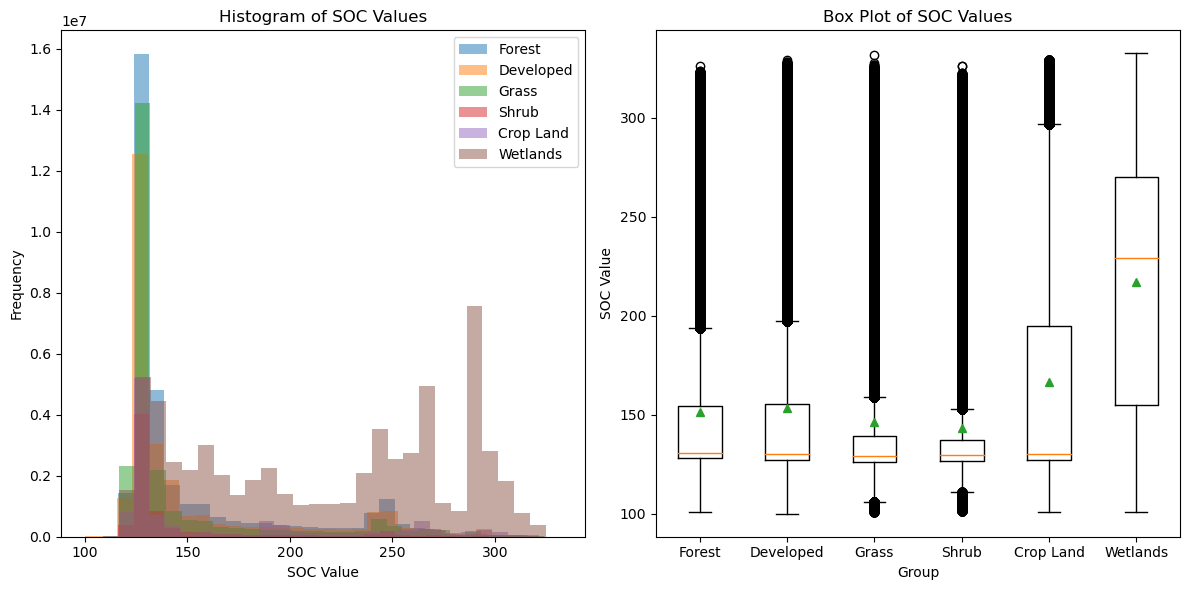

In [16]:
# 2021 landcover tif on interval
# Define your groups
categories = {
    "Forest": [41, 42, 43],
    "Developed": [21, 22, 23, 24],
    "Grass": [71, 81],
    "Shrub": [51, 52],
    "Crop Land": [82],
    "Wetlands": [90, 95]
}

# Path to the input TIFF file
tiff_path = "../FL_Inter_2021LC.tif"

# Open the TIFF file
with rasterio.open(tiff_path) as src:
    band2 = src.read(1)  # Read Band  for SOC
    band1 = src.read(2)  # Read Band for landcover


# Mask Band 2 where value is 0 (empty pixels)
band2_masked = np.where(band2 != 0, band2, np.nan)

# Initialize a dictionary to store statistics
stats = {"Group": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [] }

# Loop through each group
for group_name, values in categories.items():
    # Create a mask for the current group
    group_mask = np.isin(band1, values)
    
    # Extract corresponding Band 2 values
    selected_values = band2_masked[group_mask]
    
    # Exclude NaN values
    selected_values = selected_values[~np.isnan(selected_values)]
    
    # Calculate statistics
    mean_value = np.mean(selected_values)
    range_value = np.ptp(selected_values)  # Range: max - min
    var_value = np.var(selected_values)
    min_value = np.min(selected_values)
    max_value = np.max(selected_values)
    
    
    # Append statistics to the dictionary
    stats["Group"].append(group_name)
    stats["Mean"].append(mean_value)
    stats["Range"].append(range_value)
    stats["Variance"].append(var_value)
    stats["Min"].append(min_value)
    stats["Max"].append(max_value)

# Convert statistics to a DataFrame
stats_df = pd.DataFrame(stats)
print(stats_df)

# Save the table as a CSV
stats_df.to_csv("20241208_FL_inter_2021LC.csv", index=False)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Histogram
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    axs[0].hist(selected_values, bins=30, alpha=0.5, label=group_name)

axs[0].set_title("Histogram of SOC Values")
axs[0].set_xlabel("SOC Value")
axs[0].set_ylabel("Frequency")
axs[0].legend()

# Box Plot
box_data = []
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    box_data.append(selected_values)

axs[1].boxplot(box_data, labels=categories.keys(), showmeans=True)
axs[1].set_title("Box Plot of SOC Values")
axs[1].set_xlabel("Group")
axs[1].set_ylabel("SOC Value")

plt.tight_layout()
plt.savefig("20241208_FL_inter_2021LC.png")
plt.show()

       Group        Mean       Range     Variance        Min         Max
0     Forest  148.955109  263.832428  1567.449829  68.439972  332.272400
1  Developed  153.174911  264.154297  2020.738037  68.439972  332.594269
2      Grass  158.830002  265.130615  2177.426270  68.433228  333.563843
3      Shrub  144.590027  264.754181  1297.363403  67.840088  332.594269
4  Crop Land  185.284744  263.919617  4656.872070  68.433228  332.352844
5   Wetlands  187.489700  264.747284  3403.339844  68.703468  333.450745


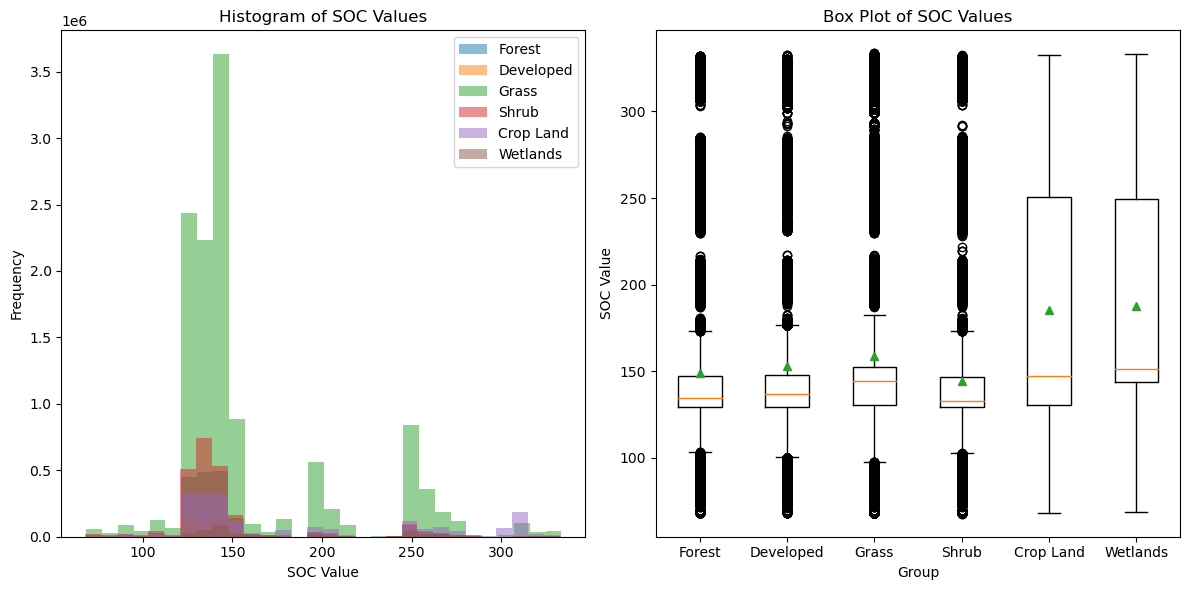

In [2]:
# 2021 landcover tif on 95 interval of SOC
# Define your groups
categories = {
    "Forest": [41, 42, 43],
    "Developed": [21, 22, 23, 24],
    "Grass": [71, 81],
    "Shrub": [51, 52],
    "Crop Land": [82],
    "Wetlands": [90, 95]
}

# Path to the input TIFF file
tiff_path = "../20250210/uncertainty_95inter_grazingland_compose_LC21.tif"

# Open the TIFF file
with rasterio.open(tiff_path) as src:
    band2 = src.read(1)  # Read Band  for SOC
    band1 = src.read(2)  # Read Band for landcover


# Mask Band 2 where value is 0 (empty pixels)
band2_masked = np.where(band2 != 0, band2, np.nan)

# Initialize a dictionary to store statistics
stats = {"Group": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [] }

# Loop through each group
for group_name, values in categories.items():
    # Create a mask for the current group
    group_mask = np.isin(band1, values)
    
    # Extract corresponding Band 2 values
    selected_values = band2_masked[group_mask]
    
    # Exclude NaN values
    selected_values = selected_values[~np.isnan(selected_values)]
    
    # Calculate statistics
    mean_value = np.mean(selected_values)
    range_value = np.ptp(selected_values)  # Range: max - min
    var_value = np.var(selected_values)
    min_value = np.min(selected_values)
    max_value = np.max(selected_values)
    
    
    # Append statistics to the dictionary
    stats["Group"].append(group_name)
    stats["Mean"].append(mean_value)
    stats["Range"].append(range_value)
    stats["Variance"].append(var_value)
    stats["Min"].append(min_value)
    stats["Max"].append(max_value)

# Convert statistics to a DataFrame
stats_df = pd.DataFrame(stats)
print(stats_df)

# Save the table as a CSV
stats_df.to_csv("../20250210/uncertainty_2021LC.csv", index=False)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Histogram
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    axs[0].hist(selected_values, bins=30, alpha=0.5, label=group_name)

axs[0].set_title("Histogram of SOC Values")
axs[0].set_xlabel("SOC Value")
axs[0].set_ylabel("Frequency")
axs[0].legend()

# Box Plot
box_data = []
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    box_data.append(selected_values)

axs[1].boxplot(box_data, labels=categories.keys(), showmeans=True)
axs[1].set_title("Box Plot of SOC Values")
axs[1].set_xlabel("Group")
axs[1].set_ylabel("SOC Value")

plt.tight_layout()
plt.savefig("../20250210/uncertainty_2021LC.png")
plt.show()

               Group        Mean       Range     Variance        Min  \
0             peanut  151.974884  261.848846  1871.884277  68.439972   
1              wheat  180.280930  252.432953  2909.556641  76.781166   
2  Alfalfa/other Hay  162.438431  265.130615  2315.883789  68.433228   
3            Oranges  159.933609  263.626007  2266.716309  68.968269   

          Max  
0  330.288818  
1  329.214111  
2  333.563843  
3  332.594269  


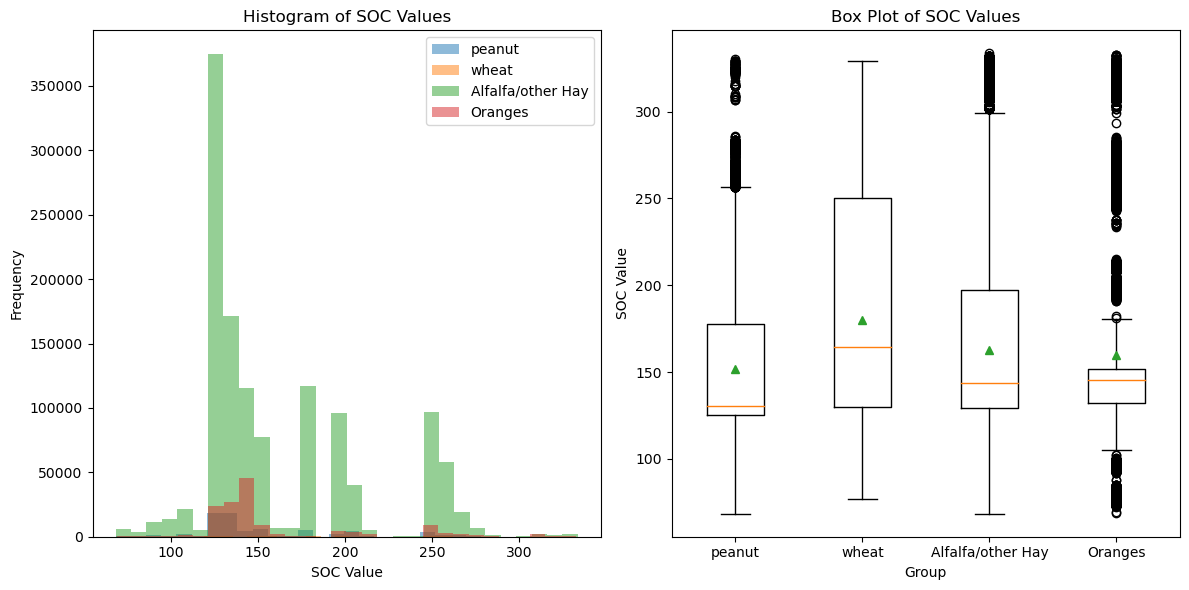

In [6]:
# 2021 cropland tif on uncertainty of 95 interval
# Define your groups
categories = {
    "peanut": [10],
    "wheat": [22, 23, 24, 39],
    "Alfalfa/other Hay": [36,37],
    "Oranges": [212]
}

# Path to the input TIFF file
tiff_path = "../20250210/uncertainty_95inter_grazingland_compose_crop21.tif"

# Open the TIFF file
with rasterio.open(tiff_path) as src:
    band2 = src.read(1)  # Read Band  for SOC
    band1 = src.read(2)  # Read Band for landcover


# Mask Band 2 where value is 0 (empty pixels)
band2_masked = np.where(band2 != 0, band2, np.nan)

# Initialize a dictionary to store statistics
stats = {"Group": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [] }

# Loop through each group
for group_name, values in categories.items():
    # Create a mask for the current group
    group_mask = np.isin(band1, values)
    
    # Extract corresponding Band 2 values
    selected_values = band2_masked[group_mask]
    
    # Exclude NaN values
    selected_values = selected_values[~np.isnan(selected_values)]
    
    # Calculate statistics
    mean_value = np.mean(selected_values)
    range_value = np.ptp(selected_values)  # Range: max - min
    var_value = np.var(selected_values)
    min_value = np.min(selected_values)
    max_value = np.max(selected_values)
    
    # Append statistics to the dictionary
    stats["Group"].append(group_name)
    stats["Mean"].append(mean_value)
    stats["Range"].append(range_value)
    stats["Variance"].append(var_value)
    stats["Min"].append(min_value)
    stats["Max"].append(max_value)

# Convert statistics to a DataFrame
stats_df = pd.DataFrame(stats)
print(stats_df)

# Save the table as a CSV
stats_df.to_csv("../20250210/uncertainty_95inter_grazingland_compose_crop21.csv", index=False)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Histogram
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    axs[0].hist(selected_values, bins=30, alpha=0.5, label=group_name)

axs[0].set_title("Histogram of SOC Values")
axs[0].set_xlabel("SOC Value")
axs[0].set_ylabel("Frequency")
axs[0].legend()

# Box Plot
box_data = []
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    box_data.append(selected_values)

axs[1].boxplot(box_data, labels=categories.keys(), showmeans=True)
axs[1].set_title("Box Plot of SOC Values")
axs[1].set_xlabel("Group")
axs[1].set_ylabel("SOC Value")

plt.tight_layout()
plt.savefig("../20250210/uncertainty_95inter_grazingland_compose_crop21.png")
plt.show()

In [11]:
# 2021 cropland tif on uncertainty of 95 interval on all crops for grazing
# Define your groups

# Path to the input TIFF file
tiff_path = "../20250210/uncertainty_95inter_grazingland_compose_crop21.tif"

# Open the TIFF file
with rasterio.open(tiff_path) as src:
    band2 = src.read(1)  # Read Band  for SOC
    band1 = src.read(2)  # Read Band for landcover


# Mask Band 2 where the value is 0 (considered empty pixels)
band2_masked = np.where(band2 != 0, band2, np.nan)

# Exclude zero values from Band 1
valid_band1 = band1[band1 != 0]
valid_band2 = band2_masked[band1 != 0]

# Get unique values in Band 1 excluding 0
unique_categories = np.unique(valid_band1)

# Initialize a dictionary to store statistics
stats = {"Category": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [], "Count": []}

# Loop through each unique value in Band 1
for category in unique_categories:
    # Create a mask for the current category in Band 1
    category_mask = valid_band1 == category
    
    # Extract corresponding Band 2 values
    selected_values = valid_band2[category_mask]
    
    # Exclude NaN values
    selected_values = selected_values[~np.isnan(selected_values)]
    
    # Skip if no valid values
    if len(selected_values) == 0:
        continue
    
    # Calculate statistics
    mean_value = np.mean(selected_values)
    range_value = np.ptp(selected_values)  # Range: max - min
    var_value = np.var(selected_values)
    min_value = np.min(selected_values)
    max_value = np.max(selected_values)
    count_value = len(selected_values)
    
    # Append statistics to the dictionary
    stats["Category"].append(int(category))
    stats["Mean"].append(mean_value)
    stats["Range"].append(range_value)
    stats["Variance"].append(var_value)
    stats["Min"].append(min_value)
    stats["Max"].append(max_value)
    stats["Count"].append(count_value)

# Convert statistics to a DataFrame
stats_df = pd.DataFrame(stats)

# Print and save the table
print(stats_df)
stats_df.to_csv("../20250210/uncertainty_95inter_grazingland_compose_crop21_all_cropsgrazing.csv", index=False)

    Category        Mean       Range     Variance         Min         Max  \
0          1  156.745804  263.358612  1940.874756   68.702904  332.061523   
1          2  143.799728  261.006042  1188.089722   68.520042  329.526093   
2          3  277.749054  189.891937  3062.350098  132.219910  322.111847   
3          4  200.505920  261.933105  6004.318359   68.732544  330.665649   
4          5  145.158264  256.695038  1188.828369   68.703468  325.398499   
..       ...         ...         ...          ...         ...         ...   
58       240  134.287750   90.645668   291.368317  110.620811  201.266479   
59       242  157.546265  255.141129  2369.201172   73.626755  328.767883   
60       243  197.407837  204.141525  3708.805176   76.279861  280.421387   
61       246  188.023575  199.797546  3367.838379  110.620811  310.418365   
62       248  165.735199  156.244049  2420.996338  110.357880  266.601929   

    Count  
0   29974  
1   24288  
2     326  
3   20896  
4    3642  
.. 

In [18]:
def getAllCategoryStatis(tiff_path,out_csv):
    # Open the TIFF file
    with rasterio.open(tiff_path) as src:
        band2 = src.read(1)  # Read Band  for SOC
        band1 = src.read(2)  # Read Band for landcover


    # Mask Band 2 where the value is 0 (considered empty pixels)
    band2_masked = np.where(band2 != 0, band2, np.nan)

    # Exclude zero values from Band 1
    valid_band1 = band1[band1 != 0]
    valid_band2 = band2_masked[band1 != 0]

    # Get unique values in Band 1 excluding 0
    unique_categories = np.unique(valid_band1)

    # Initialize a dictionary to store statistics
    stats = {"Category": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [], "Count": []}

    # Loop through each unique value in Band 1
    for category in unique_categories:
        # Create a mask for the current category in Band 1
        category_mask = valid_band1 == category
        
        # Extract corresponding Band 2 values
        selected_values = valid_band2[category_mask]
        
        # Exclude NaN values
        selected_values = selected_values[~np.isnan(selected_values)]
        
        # Skip if no valid values
        if len(selected_values) == 0:
            continue
        
        # Calculate statistics
        mean_value = np.mean(selected_values)
        range_value = np.ptp(selected_values)  # Range: max - min
        var_value = np.var(selected_values)
        min_value = np.min(selected_values)
        max_value = np.max(selected_values)
        count_value = len(selected_values)
        
        # Append statistics to the dictionary
        stats["Category"].append(int(category))
        stats["Mean"].append(mean_value)
        stats["Range"].append(range_value)
        stats["Variance"].append(var_value)
        stats["Min"].append(min_value)
        stats["Max"].append(max_value)
        stats["Count"].append(count_value)

    # Convert statistics to a DataFrame
    stats_df = pd.DataFrame(stats)

    # Print and save the table
    print(stats_df)
    stats_df.to_csv(out_csv, index=False)

tiff_path = "../20250210/uncertainty_95inter_grazingland_compose_LC21.tif"
out_csv = "../20250210/uncertainty_95inter_grazingland_compose_LC21_allCategory.csv"
getAllCategoryStatis(tiff_path=tiff_path, out_csv=out_csv)

    Category        Mean       Range     Variance        Min         Max  \
0         11  204.127563  259.727600  4016.522705  73.622261  333.349854   
1         21  150.879227  263.746521  1812.541748  68.520042  332.266571   
2         22  154.158646  264.154297  2175.650879  68.439972  332.594269   
3         23  158.671082  263.903259  2366.926758  68.439972  332.343231   
4         24  165.043961  263.129333  2809.579590  68.932190  332.061523   
5         31  171.787537  264.154297  3088.613281  68.439972  332.594269   
6         41  149.019562  263.356812  1427.073364  68.702904  332.059723   
7         42  149.117996  263.832428  1611.749390  68.439972  332.272400   
8         43  146.007111  261.473633   847.645264  68.826775  330.300415   
9         52  144.590027  264.754181  1297.363403  67.840088  332.594269   
10        71  150.694458  265.009094  2053.605713  68.440536  333.449615   
11        81  159.840988  265.130615  2183.565674  68.433228  333.563843   
12        82

In [17]:
tiff_path = "../20250210/uncertainty_95inter_grazingland_compose_LC21.tif"
out_csv = "../20250210/uncertainty_95inter_grazingland_compose_LC21_allCategory_verify.csv"
getAllCategoryStatis_update2(tiff_path=tiff_path, out_csv=out_csv)

    Category        Mean       Range     Variance        Min         Max  \
0         11  204.127563  259.727600  4016.522705  73.622261  333.349854   
1         21  150.879227  263.746521  1812.541748  68.520042  332.266571   
2         22  154.158646  264.154297  2175.650879  68.439972  332.594269   
3         23  158.671082  263.903259  2366.926758  68.439972  332.343231   
4         24  165.043961  263.129333  2809.579590  68.932190  332.061523   
5         31  171.787537  264.154297  3088.613281  68.439972  332.594269   
6         41  149.019562  263.356812  1427.073364  68.702904  332.059723   
7         42  149.117996  263.832428  1611.749390  68.439972  332.272400   
8         43  146.007111  261.473633   847.645264  68.826775  330.300415   
9         52  144.590027  264.754181  1297.363403  67.840088  332.594269   
10        71  150.694458  265.009094  2053.605713  68.440536  333.449615   
11        81  159.840988  265.130615  2183.565674  68.433228  333.563843   
12        82

In [13]:
tiff_path = "../20250210/SOC_pre_FL_grazingland_LC21.tif"
out_csv = "../20250210/SOC_pre_FL_grazingland_LC21_allCategory.csv"
getAllCategoryStatis(tiff_path=tiff_path, out_csv=out_csv)

tiff_path = "../20250210/SOC_pre_FL_grazingland_crop21.tif"
out_csv = "../20250210/SOC_pre_FL_grazingland_crop21_allCategory.csv"
getAllCategoryStatis(tiff_path=tiff_path, out_csv=out_csv)

    Category       Mean       Range     Variance        Min         Max  \
0         11  69.246880  208.910507  1477.316040  29.401869  238.312378   
1         21  45.711575  197.971512   203.666672  27.251192  225.222702   
2         22  45.635929  198.308334   279.049377  27.147261  225.455597   
3         23  46.938766  198.748764   371.486481  27.394014  226.142776   
4         24  49.869946  195.373383   563.861816  27.675560  223.048950   
5         31  49.841702  197.569839   418.070343  27.221798  224.791641   
6         41  46.337318  164.490936   147.562378  27.217920  191.708862   
7         42  45.895145  181.026291   138.529068  26.964504  207.990799   
8         43  46.619408  173.931458    82.928810  28.142015  202.073471   
9         52  43.486897  182.218140   108.798691  26.557426  208.775558   
10        71  43.676758  205.518234   195.264038  27.145758  232.663986   
11        81  50.278008  205.845718   352.011658  26.857830  232.703552   
12        82  70.858803  

In [ ]:
tiff_path = "../20250210/SOC_pre_FL_grazingland_LC21.tif"
out_csv = "../20250210/SOC_pre_FL_grazingland_LC21_allCategory.csv"
getAllCategoryStatis(tiff_path=tiff_path, out_csv=out_csv)

tiff_path = "../20250210/SOC_pre_FL_grazingland_crop21.tif"
out_csv = "../20250210/SOC_pre_FL_grazingland_crop21_allCategory.csv"
getAllCategoryStatis(tiff_path=tiff_path, out_csv=out_csv)

       Group       Mean       Range     Variance        Min         Max
0     Forest  45.945541  181.026291   135.970154  26.964504  207.990799
1  Developed  45.964394  198.995514   256.285034  27.147261  226.142776
2      Grass  49.548439  205.845718   338.971558  26.857830  232.703552
3      Shrub  43.486897  182.218140   108.798691  26.557426  208.775558
4  Crop Land  70.858803  212.569458  3236.444336  27.087015  239.656479
5   Wetlands  62.039288  211.735733   699.931946  28.460981  240.196716


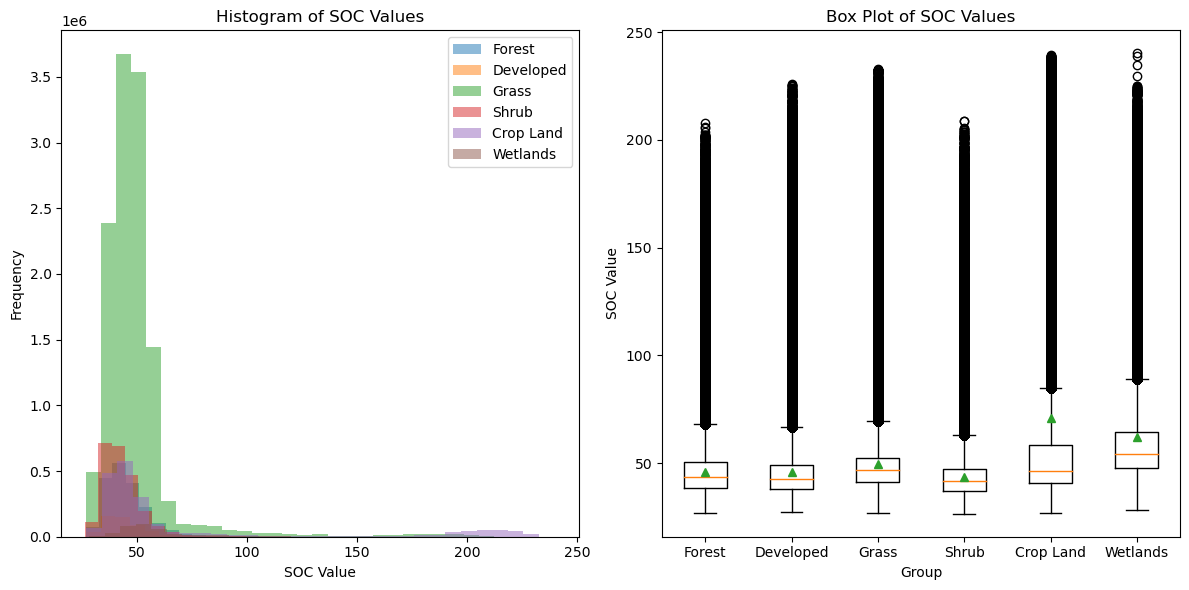

In [3]:
# 2021 landcover tif on SOC mean
# Define your groups
categories = {
    "Forest": [41, 42, 43],
    "Developed": [21, 22, 23, 24],
    "Grass": [71, 81],
    "Shrub": [51, 52],
    "Crop Land": [82],
    "Wetlands": [90, 95]
}

# Path to the input TIFF file
tiff_path = "../20250210/SOC_pre_FL_grazingland_LC21.tif"

# Open the TIFF file
with rasterio.open(tiff_path) as src:
    band2 = src.read(1)  # Read Band  for SOC
    band1 = src.read(2)  # Read Band for landcover


# Mask Band 2 where value is 0 (empty pixels)
band2_masked = np.where(band2 != 0, band2, np.nan)

# Initialize a dictionary to store statistics
stats = {"Group": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [] }

# Loop through each group
for group_name, values in categories.items():
    # Create a mask for the current group
    group_mask = np.isin(band1, values)
    
    # Extract corresponding Band 2 values
    selected_values = band2_masked[group_mask]
    
    # Exclude NaN values
    selected_values = selected_values[~np.isnan(selected_values)]
    
    # Calculate statistics
    mean_value = np.mean(selected_values)
    range_value = np.ptp(selected_values)  # Range: max - min
    var_value = np.var(selected_values)
    min_value = np.min(selected_values)
    max_value = np.max(selected_values)
    
    
    # Append statistics to the dictionary
    stats["Group"].append(group_name)
    stats["Mean"].append(mean_value)
    stats["Range"].append(range_value)
    stats["Variance"].append(var_value)
    stats["Min"].append(min_value)
    stats["Max"].append(max_value)

# Convert statistics to a DataFrame
stats_df = pd.DataFrame(stats)
print(stats_df)

# Save the table as a CSV
stats_df.to_csv("../20250210/SOC_pre_FL_grazingland_LC21.csv", index=False)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Histogram
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    axs[0].hist(selected_values, bins=30, alpha=0.5, label=group_name)

axs[0].set_title("Histogram of SOC Values")
axs[0].set_xlabel("SOC Value")
axs[0].set_ylabel("Frequency")
axs[0].legend()

# Box Plot
box_data = []
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    box_data.append(selected_values)

axs[1].boxplot(box_data, labels=categories.keys(), showmeans=True)
axs[1].set_title("Box Plot of SOC Values")
axs[1].set_xlabel("Group")
axs[1].set_ylabel("SOC Value")

plt.tight_layout()
plt.savefig("../20250210/SOC_pre_FL_grazingland_LC21.png")
plt.show()

In [ ]:
# 2021 cropland tif on SOC mean
# Define your groups
categories = {
    "Sorghum": [4],
    "Peanut": [10],
    "Barley": [21],
    "Wheat": [22, 23, 24, 39],
    "Other small Grains": [25],
    "Oats": [28],
    "Millet": [29],
    "Speltz": [30],
    "Safflower": [33],
    "Rape Seed": [34],
    "Alfalfa/other Hay": [36,37],
    "Herbs": [57],
    "Wildflowers": [58],
    "Grass Seed": [59],
    "Switchgrass": [60],
    "Fallow/Idle Cropland": [61],
    "Shrubland": [64,152],
    "Barren": [65],
    "Christmas Trees": [70],
    "Other Tree Crops": [71],
    "Barren": [131],
    "Grassland/Pasture": [176],
    "Vetch": [224],
    "Dbl Crop": [226,228, 230, 233,234,235,236,237,238],

}

# Path to the input TIFF file
tiff_path = "../20250210/SOC_pre_FL_grazingland_crop21.tif"

# Open the TIFF file
with rasterio.open(tiff_path) as src:
    band2 = src.read(1)  # Read Band  for SOC
    band1 = src.read(2)  # Read Band for landcover


# Mask Band 2 where value is 0 (empty pixels)
band2_masked = np.where(band2 != 0, band2, np.nan)

# Initialize a dictionary to store statistics
stats = {"Group": [], "Mean": [], "Range": [], "Variance": [], "Min": [], "Max": [] }

# Loop through each group
for group_name, values in categories.items():
    # Create a mask for the current group
    group_mask = np.isin(band1, values)
    
    # Extract corresponding Band 2 values
    selected_values = band2_masked[group_mask]
    
    # Exclude NaN values
    selected_values = selected_values[~np.isnan(selected_values)]
    
    # Calculate statistics
    mean_value = np.mean(selected_values)
    range_value = np.ptp(selected_values)  # Range: max - min
    var_value = np.var(selected_values)
    min_value = np.min(selected_values)
    max_value = np.max(selected_values)
    
    # Append statistics to the dictionary
    stats["Group"].append(group_name)
    stats["Mean"].append(mean_value)
    stats["Range"].append(range_value)
    stats["Variance"].append(var_value)
    stats["Min"].append(min_value)
    stats["Max"].append(max_value)

# Convert statistics to a DataFrame
stats_df = pd.DataFrame(stats)
print(stats_df)

# Save the table as a CSV
stats_df.to_csv("../20250210/SOC_pre_FL_grazingland_crop21.csv", index=False)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Histogram
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    axs[0].hist(selected_values, bins=30, alpha=0.5, label=group_name)

axs[0].set_title("Histogram of SOC Values")
axs[0].set_xlabel("SOC Value")
axs[0].set_ylabel("Frequency")
axs[0].legend()

# Box Plot
box_data = []
for group_name in categories.keys():
    group_mask = np.isin(band1, categories[group_name])
    selected_values = band2_masked[group_mask]
    selected_values = selected_values[~np.isnan(selected_values)]
    box_data.append(selected_values)

axs[1].boxplot(box_data, labels=categories.keys(), showmeans=True)
axs[1].set_title("Box Plot of SOC Values")
axs[1].set_xlabel("Group")
axs[1].set_ylabel("SOC Value")

plt.tight_layout()
plt.savefig("../20250210/SOC_pre_FL_grazingland_crop21.png")
plt.show()

In [16]:
# 90 interval width map
# Define your groups

tiff_path = "../20250210/uncertainty_90inter_grazingland_compose_crop21.tif"
out_csv = "../20250210/uncertainty_90inter_grazingland_compose_crop21_2.csv"
getAllCategoryStatis_update2(tiff_path=tiff_path, out_csv=out_csv)

tiff_path = "../20250210/uncertainty_90inter_grazingland_compose_LC21.tif"
out_csv = "../20250210/uncertainty_90inter_grazingland_compose_LC21_2.csv"
getAllCategoryStatis_update2(tiff_path=tiff_path, out_csv=out_csv)


    Category        Mean       Range     Variance         Min         Max  \
0          1  110.030975  266.430664  1269.258667   45.023849  311.454529   
1          2  101.189339  230.692184   991.138306   43.499073  274.191254   
2          3  259.251404  199.443298  3449.539062  107.102051  306.545349   
3          4  156.856735  274.356171  4515.788086   45.603107  319.959290   
4          5  105.289238  224.524414   863.434937   45.876377  270.400787   
..       ...         ...         ...          ...         ...         ...   
58       240  111.112709  194.573914  1183.832275   62.902153  257.476074   
59       242  119.973061  256.278259  2115.399902   51.139896  307.418152   
60       243  115.702667  209.289383  1386.476807   47.142742  256.432129   
61       246  152.252777  241.598801  2841.926025   64.938004  306.536804   
62       248  124.515358  184.749756  1653.657227   61.639824  246.389572   

    Count  
0   26704  
1   21312  
2     264  
3   25222  
4    3278  
.. 

In [2]:
# sum of SOC prediction in grazing land
# Load the TIFF file
tiff_path = "../20250210/SOC_pre_FL_grazingland.tif"  # Replace with the actual file path

with rasterio.open(tiff_path) as src:
    data = src.read()  # Read all bands as a NumPy array

# Compute sum while ignoring NoData values (if present)
nodata_value = src.nodatavals[0]  # Get NoData value for the first band
if nodata_value is not None:
    data = np.where(data == nodata_value, np.nan, data)  # Replace NoData with NaN

total_sum = np.nansum(data)  # Compute sum while ignoring NaN values

print(f"Total sum of all pixel values: {total_sum}")

pixel_area_ha = (30 * 30) / 10000  # Convert 900 m² to hectares (0.09 ha)
total_tons = total_sum * pixel_area_ha

print(f"Total mass in tons: {total_tons}")

Total sum of all pixel values: 1013404288.0


In [3]:
pixel_area_ha = (30 * 30) / 10000  # Convert 900 m² to hectares (0.09 ha)
total_tons = total_sum * pixel_area_ha

print(f"Total mass in tons: {total_tons}")

Total mass in tons: 91206385.92


In [6]:
tiff_path = "../20250210/SOC_pre_FL_grazingland.tif" 

with rasterio.open(tiff_path) as src:
    data = src.read(1)  # Read the first band (modify if multi-band)
    nodata_value = src.nodatavals[0]  # Get NoData value (if defined)

# Replace NoData values and 0 with NaN
if nodata_value is not None:
    data = np.where((data == nodata_value) | (data == 0), np.nan, data)
else:
    data = np.where(data == 0, np.nan, data)  # Just remove 0 if NoData is not defined

# Compute sum and count valid pixels
total_sum = np.nansum(data)  # Sum of valid pixels
valid_pixel_count = np.count_nonzero(~np.isnan(data))  # Count of valid pixels

# Compute the average
average_value = total_sum / valid_pixel_count if valid_pixel_count > 0 else np.nan

print(f"Average pixel value (excluding NoData and 0): {average_value:.2e}")
print(valid_pixel_count)
print(data.shape)

Average pixel value (excluding NoData and 0): 5.08e+01
19946971
(21566, 25699)


In [7]:
print(f"Average pixel value (excluding NoData and 0): {average_value}")

Average pixel value (excluding NoData and 0): 50.804921108071994


In [19]:
def compute_tiff_statistics(tiff_path):
    with rasterio.open(tiff_path) as src:
        data = src.read(1)  # Read the first band
        nodata_value = src.nodatavals[0]  # Get NoData value (if defined)

    # Replace NoData values and 0 with NaN
    if nodata_value is not None:
        data = np.where((data == nodata_value) | (data == 0), np.nan, data)
    else:
        data = np.where(data == 0, np.nan, data)  # Remove 0 if NoData is not defined

    # Extract valid pixels
    valid_pixels = data[~np.isnan(data)]

    # Compute statistics
    count = len(valid_pixels)
    total_sum = np.nansum(valid_pixels)
    mean = np.nanmean(valid_pixels)
    median = np.nanmedian(valid_pixels)
    min_val = np.nanmin(valid_pixels)
    max_val = np.nanmax(valid_pixels)
    std_dev = np.nanstd(valid_pixels)
    cv = (std_dev / mean) * 100 if mean != 0 else np.nan  # Coefficient of Variation (CV%)

    # Print results
    print(f"Count: {count}")
    print(f"Sum: {total_sum}")
    print(f"Mean: {mean}")
    print(f"Median: {median}")
    print(f"Min: {min_val}")
    print(f"Max: {max_val}")
    print(f"StdDev: {std_dev}")
    print(f"CV (%): {cv}")

    # Return results as a dictionary
    return {
        "Count": count,
        "Sum": total_sum,
        "Mean": mean,
        "Median": median,
        "Min": min_val,
        "Max": max_val,
        "StdDev": std_dev,
        "CV (%)": cv
    }

# Example usage
tiff_path = "../20250210/SOC_pre_FL_grazingland.tif"  # Replace with actual file path
stats = compute_tiff_statistics(tiff_path)

Count: 19946971
Sum: 1013403136.0
Mean: 50.80486297607422
Median: 45.9698486328125
Min: 26.55742645263672
Max: 240.19671630859375
StdDev: 25.386653900146484
CV (%): 49.96894598007202


In [18]:
# Example usage
tiff_path = "C:/Users/zhou.tang/OneDrive - University of Florida/1_SOC/tiff_output/20212025_Finalize/avg_grazing_singleband.tif"  # Replace with actual file path
stats = compute_tiff_statistics(tiff_path)

Count: 19947327
Sum: 1013412672.0
Mean: 50.80443572998047
Median: 45.969783782958984
Min: 26.55742645263672
Max: 241.57742309570312
StdDev: 25.38547134399414
CV (%): 49.96703863143921


In [17]:
tiff_path = "../20250210/prediction_44bands_qrf_90_interval_grazing.tif"  # Replace with actual file path
stats = compute_tiff_statistics(tiff_path)

Count: 23370557
Sum: 2804106496.0
Mean: 119.98458099365234
Median: 114.53658294677734
Min: 43.1636848449707
Max: 327.8180847167969
StdDev: 45.03807830810547
CV (%): 37.53655552864075


In [14]:
# (19946971 * 30 * 30 / 10000 )
17952.27 / 147362

0.12182428305804753

In [15]:
652266.63 / 147362

4.426287848970563

In [ ]:
tiff_path = "../20250210/uncertainty_90inter_grazingland_compose_LC21.tif"
out_csv = "../20250210/uncertainty_90inter_grazingland_compose_LC21_2.csv"
getAllCategoryStatis_update2(tiff_path=tiff_path, out_csv=out_csv)